# Comparison of in vitro endothelium with in vivo embryos

In [1]:
here::i_am("revisions/06_endothelium_verification/endothelium_comparison_atlases.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(Seurat))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(edgeR))

BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 21

# Multi core using future - built in to seurat
plan("multicore", workers = 16)
options(future.globals.maxSize = 50 * 1024 ^ 3) # for 50 Gb RAM

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code

Warning message:
“package ‘rtracklayer’ was built under R version 4.2.3”


In [40]:
args = list()

# Metadata
args$metadata = file.path(io$basedir, 'results/rna_atac/clustering/metadata_celltype_annotated_v2.txt.gz')

# RNA_sce
args$rna_sce = file.path(io$basedir, 'processed/rna/SingleCellExperiment.rds')

# outdir
args$outdir = file.path(io$basedir, 'results/rna_atac/celltype_markers/')
dir.create(args$outdir, recursive=TRUE, showWarnings =FALSE)

In [41]:
# Load meta
meta = fread(args$metadata) %>% 
    .[celltype_v2 == 'Endothelium']  # Only WT cells for celltype marker search

In [4]:
# load sce
rna.sce <- load_SingleCellExperiment(args$rna_sce, normalise = TRUE, cells = meta$cell)
colData(rna.sce) = meta %>% as.data.frame() %>% tibble::column_to_rownames('cell') %>% DataFrame()

#### Quick plot of endothelial markers

In [50]:
head(meta)

cell,barcode,sample,nFeature_RNA,nCount_RNA,mitochondrial_percent_RNA,ribosomal_percent_RNA,alias,day,genotype,⋯,stage.mapped_mnn,cellstage.score_mnn,closest.cell_mnn,celltype_genotype,celltype_extended_genotype,UMAP1,UMAP2,mofa_cluster,celltype_v1,celltype_v2
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>,⋯,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>,<chr>,<chr>
2_Eo_DEG_G9_day4_VC#GTACTGGTCTTAAGTG-1,GTACTGGTCTTAAGTG-1,2_Eo_DEG_G9_day4_VC,4603,14339,6.17,6.82,day4_WT_rep2,D4,WT,⋯,E8.5,0.56,cell_92339,Endothelium-WT,Venous_endothelium-WT,7.110783,0.9862596,15,Endothelium,Endothelium
2_Eo_DEG_G9_day4_VC#TGGACCGGTTGGGTTA-1,TGGACCGGTTGGGTTA-1,2_Eo_DEG_G9_day4_VC,3661,9320,5.46,14.28,day4_WT_rep2,D4,WT,⋯,E7.0,0.40,cell_88290,Mixed_mesoderm-WT,Lateral_plate_mesoderm-WT,6.922214,1.0375621,15,Endothelium,Endothelium
2_Eo_DEG_G9_day4_VC#TGTGCACCAGCAAGGC-1,TGTGCACCAGCAAGGC-1,2_Eo_DEG_G9_day4_VC,4288,12321,4.91,8.77,day4_WT_rep2,D4,WT,⋯,E8.5,0.64,cell_92339,Haematoendothelial_progenitors-WT,Venous_endothelium-WT,7.277101,0.9686094,15,Endothelium,Endothelium
2_Eo_DEG_G9_day4_dTAG#AACAGATAGTTGGATC-1,AACAGATAGTTGGATC-1,2_Eo_DEG_G9_day4_dTAG,3061,8064,9.40,17.88,day4_KO_rep2,D4,KO,⋯,E8.0,0.56,cell_73455,ExE_mesoderm-KO,Lateral_plate_mesoderm-KO,7.482838,1.1158436,15,Endothelium,Endothelium
2_Eo_DEG_G9_day4_dTAG#ACGGGAAGTGATGGCT-1,ACGGGAAGTGATGGCT-1,2_Eo_DEG_G9_day4_dTAG,3434,8545,11.83,9.50,day4_KO_rep2,D4,KO,⋯,E8.5,0.32,cell_99233,Endothelium-KO,Venous_endothelium-KO,7.350658,1.3768554,15,Endothelium,Endothelium
2_Eo_DEG_G9_day4_dTAG#CACCGGTAGCCTGATG-1,CACCGGTAGCCTGATG-1,2_Eo_DEG_G9_day4_dTAG,4658,14306,3.45,7.99,day4_KO_rep2,D4,KO,⋯,E8.5,0.32,cell_12207,Endothelium-KO,Venous_endothelium-KO,7.353368,1.0704208,15,Endothelium,Endothelium


In [66]:
subset_markers = fread('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation/SS2/Endothelial_subset_markers.txt')

In [286]:
top_markers = subset_markers %>% 
    .[cluster != 'embryo'] %>%
    .[,head(.SD, 15), by = 'cluster'] %>% 
    .[gene %in% rownames(rna.sce)]

In [287]:
tmp = mclapply(unique(top_markers$gene), function(x){
    tmp = meta %>% copy() %>%
    .[,value := minmax.normalisation(as.vector(logcounts(rna.sce[x,meta$cell])))] %>% 
    .[,gene := x]
    return(tmp)
}, mc.cores = 12) %>% rbindlist() %>%
   .[order(genotype)] %>% 
    .[,gene := factor(gene, levels = top_markers$gene)]

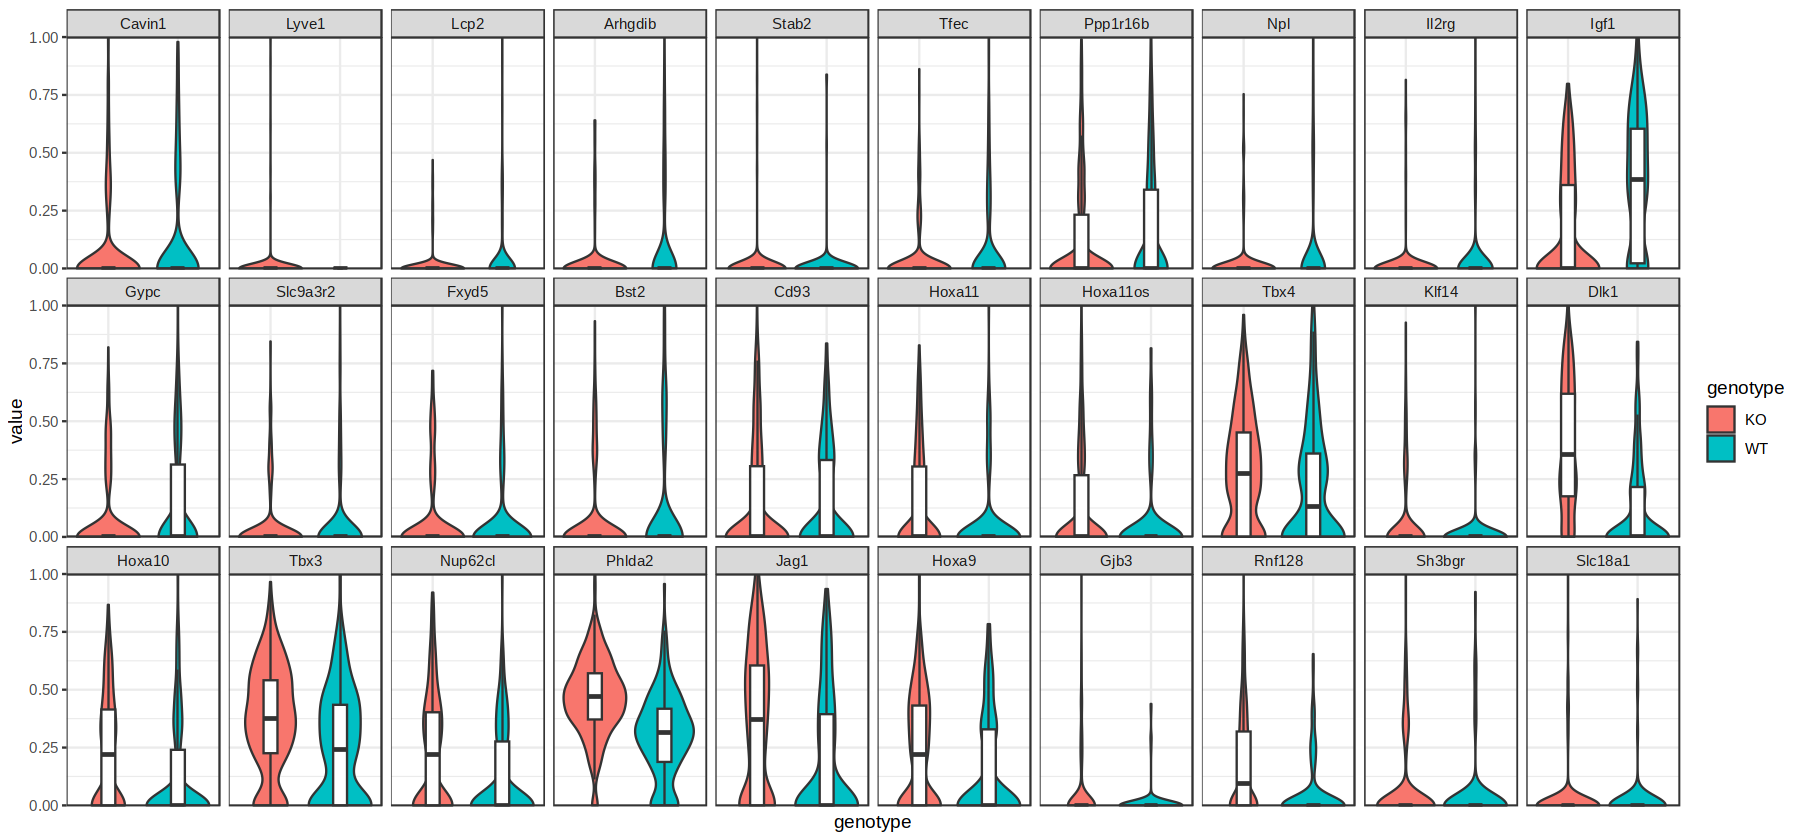

In [288]:
options(repr.plot.height=7, repr.plot.width = 15)

ggplot(tmp, aes(genotype, value, fill = genotype)) + 
    geom_violin() + 
    geom_boxplot(fill = 'white', width = 0.2, outlier.shape = NA) + 
    facet_wrap(~gene, ncol = 10) + 
    scale_y_continuous(expand = c(0,0)) + 
    theme_bw() + 
    theme(axis.text.x = element_blank(),
          axis.ticks.x = element_blank())

In [115]:
head(top_markers)

cluster,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,gene
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
yolk sac,2.852431e-34,2.070508,0.911,0.219,1.433033e-29,Cavin1
yolk sac,3.475243e-34,2.048852,0.989,0.469,1.745927e-29,Lyve1
yolk sac,7.480506e-34,2.353611,0.822,0.106,3.758132e-29,Lcp2
yolk sac,5.302134e-31,1.307636,0.956,0.562,2.663739e-26,Arhgdib
yolk sac,3.618046e-29,2.462631,0.733,0.081,1.817670e-24,Stab2
yolk sac,2.478745e-28,2.006054,0.778,0.100,1.245297e-23,Tfec


In [178]:
top_markers = subset_markers %>% 
     #.[cluster != 'embryo'] %>%
    .[,head(.SD, 10), by = 'cluster'] %>% 
    .[gene %in% rownames(rna.sce)]

In [179]:
tmp = mclapply(unique(top_markers$gene), function(x){
    tmp = meta %>% copy() %>%
    .[,value := minmax.normalisation(as.vector(logcounts(rna.sce[x,meta$cell])))] %>% 
    .[,gene := x]
    return(tmp)
}, mc.cores = 12) %>% rbindlist() %>%
   .[order(genotype)] %>% 
    .[,gene := factor(gene, levels = top_markers$gene)]

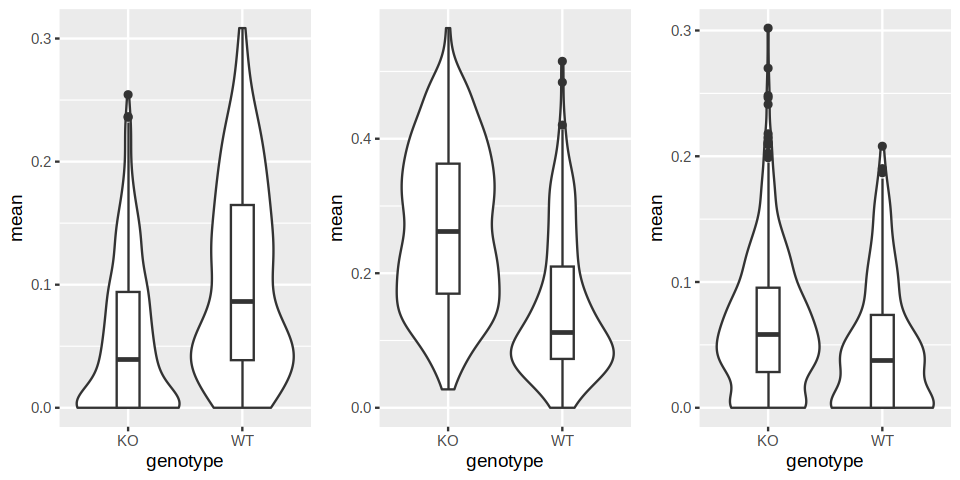

In [180]:
tmp1 = tmp %>% copy %>%
    .[gene %in% top_markers[cluster == 'yolk sac', gene]] %>%
    .[, mean := mean(value), by = 'cell'] %>%
    unique(by = 'cell')
p1 = ggplot(tmp1, aes(genotype, mean)) + 
    geom_violin(scale = 'width') + 
    geom_boxplot(width = 0.2)

tmp1 = tmp %>% copy %>%
    .[gene %in% top_markers[cluster == 'allantois', gene]] %>%
    .[, mean := mean(value), by = 'cell'] %>%
    unique(by = 'cell')
p2 = ggplot(tmp1, aes(genotype, mean)) + 
    geom_violin(scale = 'width') + 
    geom_boxplot(width = 0.2)

tmp1 = tmp %>% copy %>%
    .[gene %in% top_markers[cluster == 'embryo', gene]] %>%
    .[, mean := mean(value), by = 'cell'] %>%
    unique(by = 'cell')
p3 = ggplot(tmp1, aes(genotype, mean)) + 
    geom_violin(scale = 'width') + 
    geom_boxplot(width = 0.2)

options(repr.plot.height=4, repr.plot.width = 8)
ggarrange(p1, p2, p3, nrow = 1)

In [181]:
decomp <- modelGeneVar(rna.sce)
decomp <- decomp[decomp$mean > 0.01,]
hvgs <- decomp[order(decomp$FDR),] %>% head(n=500) %>% rownames

# Subset SingleCellExperiment
sce_filt <- rna.sce[hvgs,]

In [230]:
sce_filt <- runPCA(sce_filt, ncomponents = 5, ntop=100)  


In [251]:
rotation = as.data.table(attr(sce_filt@int_colData@listData$reducedDims$PCA, which = 'rotation'), keep.rownames = T)

In [231]:
sce_filt <- runUMAP(sce_filt, dimred="PCA", n_neighbors = 15, min_dist = 0.7)


In [232]:
to.plot <- reducedDim(sce_filt,"PCA") %>% as.data.table %>% 
    .[,cell:=colnames(sce_filt)] %>%
    merge(meta, by="cell")

In [536]:
  p <- ggplot(to.plot, aes(x=PC1, y=PC2, col=genotype)) +
    geom_point(size=2) +
    theme_classic() +
    theme(
      axis.title = element_blank(),
      axis.text = element_blank(),
      axis.ticks = element_blank()
    )
p

ERROR while rich displaying an object: Error in `geom_point()`:
! Problem while computing aesthetics.
ℹ Error occurred in the 1st layer.
Caused by error in `FUN()`:
! object 'PC1' not found

Traceback:
1. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
2. tryCatchList(expr, classes, parentenv, handlers)
3. tryCatchOne(expr, names, parentenv, handlers[[1L]])
4. doTryCatch(return(expr), name, parentenv, handler)
5. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error

In [324]:
x = 'Mrc1'
options(repr.plot.height=4, repr.plot.width = 7)
to.plot = to.plot %>% copy() %>% .[,value := as.vector(logcounts(rna.sce[x,to.plot$cell]))]
  p <- ggplot(to.plot, aes(x=PC1, y=PC2, col=value)) +
    geom_point(size=2) +
    scale_color_gradientn(colours = rainbow(5)) + 
    facet_wrap
    theme_classic() +
    theme(
      axis.title = element_blank(),
      axis.text = element_blank(),
      axis.ticks = element_blank()
    )
p

ERROR: [1m[33mError[39m in `ggplot_add()`:[22m
[1m[22m[33m![39m Can't add `facet_wrap` to a [34m<ggplot>[39m object
[36mℹ[39m Did you forget to add parentheses, as in `facet_wrap()`?


#### Atlas

In [434]:
# Load Atlas
args$atlas.sce = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/endothelium/endothelium_sce.rds'
atlas.sce = load_SingleCellExperiment(args$atlas.sce, normalise = TRUE) 
atlas.sce = atlas.sce[,atlas.sce$seurat_cluster %in% c('YS_endothelium', 'Allantois_endothelium')]

In [435]:
atlas_meta = colData(atlas.sce) %>% as.data.table(keep.rownames=T) %>% setnames('rn', 'cell')

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


In [280]:
tmp = mclapply(unique(top_markers$gene), function(x){
    tmp = atlas_meta %>% copy() %>%
    .[,value := as.vector(logcounts(atlas.sce[x,atlas_meta$cell]))] %>% 
    .[,gene := x]
    return(tmp)
}, mc.cores = 12) %>% rbindlist() %>%
   .[order(genotype)] %>% 
    .[,gene := factor(gene, levels = top_markers$gene)]

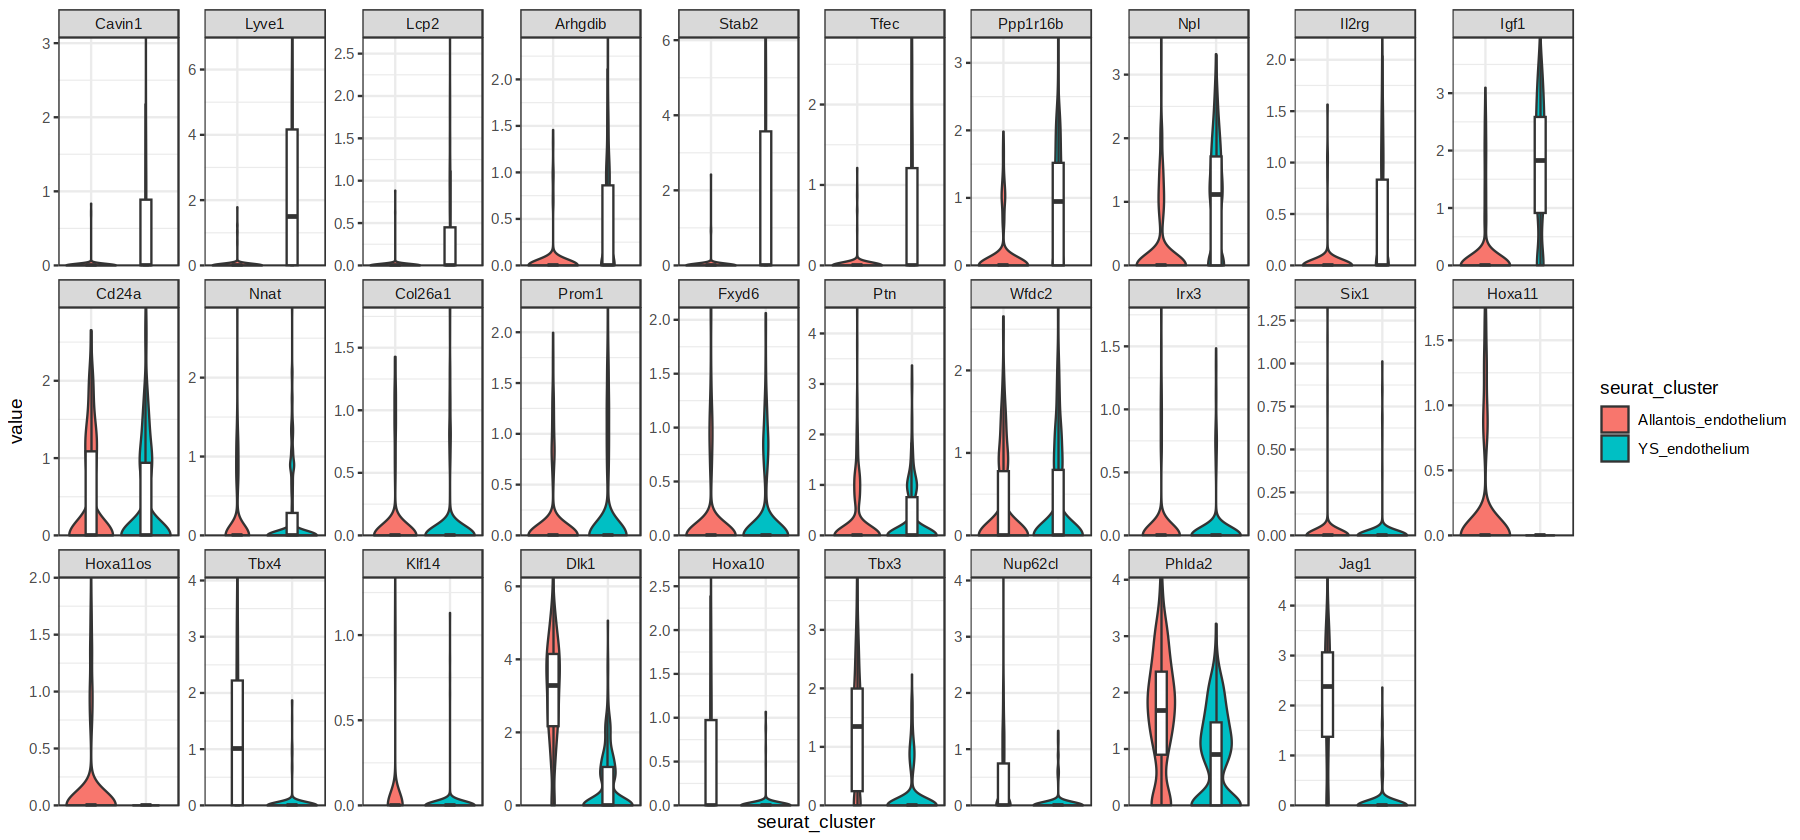

In [282]:
options(repr.plot.height=7, repr.plot.width = 15)
ggplot(tmp, aes(seurat_cluster, value, fill = seurat_cluster)) + 
    geom_violin() + 
    geom_boxplot(fill = 'white', width = 0.2, outlier.shape = NA) + 
    facet_wrap(~gene, ncol = 10, scale = 'free') + 
    scale_y_continuous(expand = c(0,0)) + 
    theme_bw() + 
    theme(axis.text.x = element_blank(),
          axis.ticks.x = element_blank())

In [487]:
seurat = as.Seurat(atlas.sce)
Idents(seurat) = seurat$seurat_cluster
markers = as.data.table(FindMarkers(seurat, ident.1 = 'YS_endothelium', ident.2 = 'Allantois_endothelium'), keep.rownames=T) %>%
    .[, sig := ifelse(avg_log2FC > 0 & p_val_adj < 0.05, 'pos',
                      ifelse(avg_log2FC < 0 & p_val_adj < 0.05, 'neg',
                             'nonsig'))]

In [488]:
head(markers)

rn,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,sig
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Jag1,2.198402e-90,-1.500614,0.108,0.866,3.360697e-86,neg
Nrg1,7.025742e-88,1.621138,0.906,0.124,1.074025e-83,pos
Dlk1,1.659774e-78,-1.356876,0.439,0.935,2.537297e-74,neg
Flt1,8.458727e-77,0.701834,1.000,0.852,1.293086e-72,pos
Meis1,1.115188e-75,1.228552,0.920,0.320,1.704788e-71,pos
Hoxa9,2.484164e-74,-1.078709,0.033,0.715,3.797542e-70,neg


In [498]:
table(markers$sig)


   neg nonsig    pos 
   377     16    769 

In [495]:
tmp = mclapply(markers[sig=='pos', rn], function(x){
    tmp = meta %>% copy() %>%
    .[,value := minmax.normalisation(as.vector(logcounts(rna.sce[x,meta$cell])))] %>% 
    .[,gene := x]
    return(tmp)
}, mc.cores = 12) %>% rbindlist() %>%
   .[order(genotype)] %>% 
    .[,gene := factor(gene, levels = top_markers$gene)]

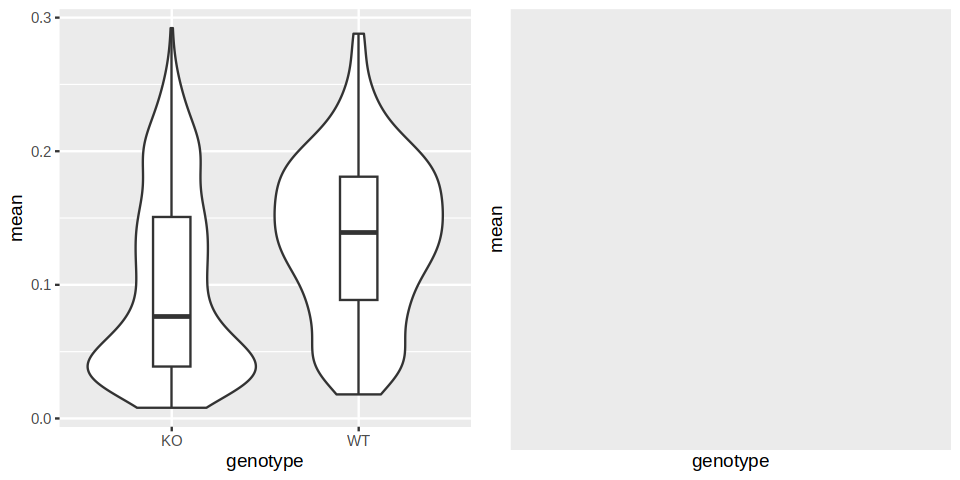

In [496]:
tmp1 = tmp %>% copy %>%
    .[gene %in% markers[sig=='pos', rn]] %>%
    .[, mean := mean(value), by = 'cell'] %>%
    unique(by = 'cell')
p1 = ggplot(tmp1, aes(genotype, mean)) + 
    geom_violin(scale = 'width') + 
    geom_boxplot(width = 0.2)

tmp1 = tmp %>% copy %>%
    .[gene %in% markers[sig=='neg', rn]] %>%
    .[, mean := mean(value), by = 'cell'] %>%
    unique(by = 'cell')
p2 = ggplot(tmp1, aes(genotype, mean)) + 
    geom_violin(scale = 'width') + 
    geom_boxplot(width = 0.2)

options(repr.plot.height=4, repr.plot.width = 8)
ggarrange(p1, p2, nrow = 1)

In [503]:
tmp1 = tmp %>% copy %>%
    .[gene %in% markers[sig=='pos', rn]] %>%
    .[, mean := mean(value), by = 'cell'] %>%
    unique(by = 'cell')
head(tmp1)

cell,barcode,sample,nFeature_RNA,nCount_RNA,mitochondrial_percent_RNA,ribosomal_percent_RNA,alias,day,genotype,⋯,celltype_genotype,celltype_extended_genotype,UMAP1,UMAP2,mofa_cluster,celltype_v1,celltype_v2,value,gene,mean
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<dbl>,<dbl>,<int>,<chr>,<chr>,<dbl>,<fct>,<dbl>
2_Eo_DEG_G9_day4_dTAG#AACAGATAGTTGGATC-1,AACAGATAGTTGGATC-1,2_Eo_DEG_G9_day4_dTAG,3061,8064,9.40,17.88,day4_KO_rep2,D4,KO,⋯,ExE_mesoderm-KO,Lateral_plate_mesoderm-KO,7.482838,1.115844,15,Endothelium,Endothelium,0.0000000,Nrg1,0.01131298
2_Eo_DEG_G9_day4_dTAG#ACGGGAAGTGATGGCT-1,ACGGGAAGTGATGGCT-1,2_Eo_DEG_G9_day4_dTAG,3434,8545,11.83,9.50,day4_KO_rep2,D4,KO,⋯,Endothelium-KO,Venous_endothelium-KO,7.350658,1.376855,15,Endothelium,Endothelium,0.0000000,Nrg1,0.15520370
2_Eo_DEG_G9_day4_dTAG#CACCGGTAGCCTGATG-1,CACCGGTAGCCTGATG-1,2_Eo_DEG_G9_day4_dTAG,4658,14306,3.45,7.99,day4_KO_rep2,D4,KO,⋯,Endothelium-KO,Venous_endothelium-KO,7.353368,1.070421,15,Endothelium,Endothelium,0.0000000,Nrg1,0.09397962
2_Eo_DEG_G9_day4_dTAG#GCATGAAAGCCTGTTC-1,GCATGAAAGCCTGTTC-1,2_Eo_DEG_G9_day4_dTAG,4741,14305,3.38,8.65,day4_KO_rep2,D4,KO,⋯,Endothelium-KO,Venous_endothelium-KO,7.750730,1.967296,15,Endothelium,Endothelium,0.0000000,Nrg1,0.07250890
2_Eo_DEG_G9_day5_dTAG#AAACCGCGTTAATGCG-1,AAACCGCGTTAATGCG-1,2_Eo_DEG_G9_day5_dTAG,4889,15446,5.77,9.59,day5_KO_rep1,D5,KO,⋯,Haematoendothelial_progenitors-KO,Allantois_endothelium-KO,7.507001,3.882644,15,Endothelium,Endothelium,0.0000000,Nrg1,0.04408378
2_Eo_DEG_G9_day5_dTAG#AAAGCAAGTTGCTTCG-1,AAAGCAAGTTGCTTCG-1,2_Eo_DEG_G9_day5_dTAG,4441,13085,4.69,10.37,day5_KO_rep1,D5,KO,⋯,Haematoendothelial_progenitors-KO,Allantois_endothelium-KO,7.474784,3.963420,15,Endothelium,Endothelium,0.2495846,Nrg1,0.02654670


### Integrate data

In [436]:
colnames(colData(rna.sce))
colnames(colData(atlas.sce))

[1] "barcode"                      "sample"                      
 [3] "nFeature_RNA"                 "nCount_RNA"                  
 [5] "mitochondrial_percent_RNA"    "ribosomal_percent_RNA"       
 [7] "alias"                        "day"                         
 [9] "genotype"                     "replicate"                   
[11] "pass_rnaQC"                   "doublet_score"               
[13] "doublet_call"                 "celltype.mapped_mnn"         
[15] "celltype.score_mnn"           "celltype_extended.mapped_mnn"
[17] "celltype_extended.score_mnn"  "stage.mapped_mnn"            
[19] "cellstage.score_mnn"          "closest.cell_mnn"            
[21] "celltype_genotype"            "celltype_extended_genotype"  
[23] "UMAP1"                        "UMAP2"                       
[25] "mofa_cluster"                 "celltype_v1"                 
[27] "celltype_v2"

[1] "barcode"                   "sample"                   
 [3] "nFeature_RNA"              "nCount_RNA"               
 [5] "mitochondrial_percent_RNA" "ribosomal_percent_RNA"    
 [7] "stage"                     "genotype"                 
 [9] "pass_rnaQC"                "doublet_score"            
[11] "doublet_call"              "celltype"                 
[13] "celltype.score"            "closest.cell"             
[15] "pass_atacQC"               "seurat_cluster"           
[17] "sizeFactor"

In [437]:
rna.sce2 = rna.sce
colData(rna.sce2) = colData(rna.sce2)[,c('genotype', 'barcode')]

atlas.sce2 = atlas.sce
colData(atlas.sce2) = colData(atlas.sce2)[,c('genotype', 'barcode')]

In [438]:
genes = intersect(rownames(rna.sce2), rownames(atlas.sce2))
sce = cbind(atlas.sce2[genes,], rna.sce2[genes,])

In [439]:
sce$genotype = ifelse(is.na(sce$genotype), 'Atlas', sce$genotype)

In [440]:
top_markers = subset_markers %>% 
    .[cluster != 'embryo'] %>%
    .[gene %in% rownames(rna.sce)]

In [441]:
nrow(top_markers)

[1] 238

In [442]:
library(batchelor)

In [443]:
pca.mtx <- multiBatchPCA(sce[top_markers$gene,], 
                         batch = colData(sce)$genotype, 
                         d = 5,
                         preserve.single=TRUE, 
                         BPPARAM  = BPPARAM)[[1]]
colnames(pca.mtx) <- paste0("PC",1:ncol(pca.mtx))
reducedDim(sce, "PCA") <- pca.mtx[colnames(sce),]

In [444]:
pca.corrected <- reducedMNN(pca.mtx, batch = colData(sce)$genotype, auto.merge = TRUE)$corrected 


In [445]:
reducedDim(sce, "PCA_corrected") <- pca.corrected[colnames(sce),]

In [446]:
to.plot <- as.data.table(pca.corrected, keep.rownames=T) %>% setnames('rn', 'cell') %>% as.data.table %>% 
    .[,cell:=colnames(sce)] %>% 
    .[,genotype := colData(sce)$genotype]

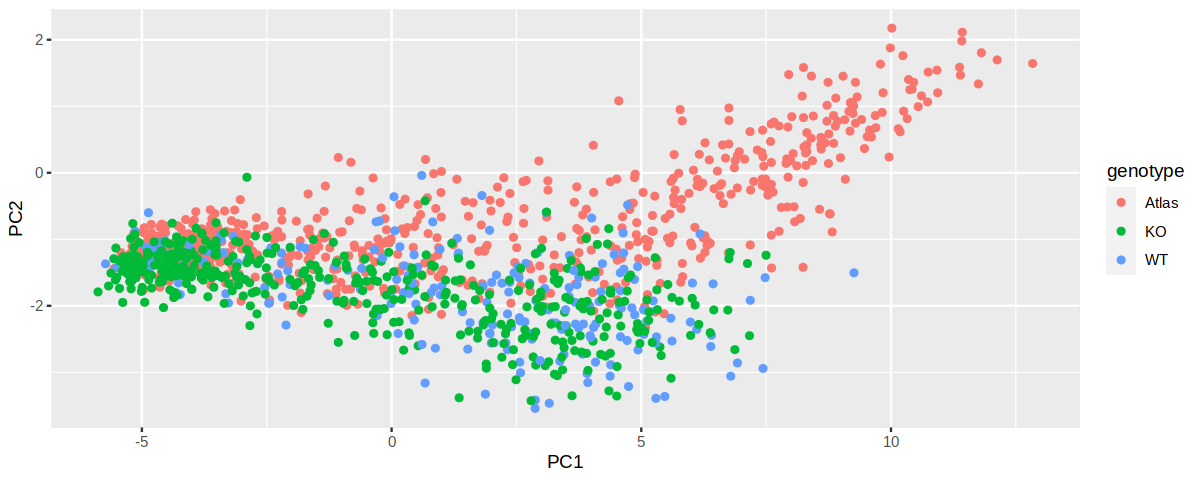

In [447]:
ggplot(to.plot, aes(PC1, PC2, color = genotype)) + 
    geom_point()

In [448]:
set.seed(1234)
args$min_dist = 0.3
args$n_neighbors = 15

umap.mtx = uwot::umap(reducedDim(sce, "PCA_corrected")[colnames(sce),], 
                n_neighbors = args$n_neighbors,
                min_dist = args$min_dist)

In [449]:
reducedDim(sce, "UMAP") <- umap.mtx[colnames(sce),]

In [450]:
to.plot <- as.data.table(umap.mtx, keep.rownames=T) %>% setnames('rn', 'cell') %>% as.data.table %>% 
    .[,cell:=colnames(sce)] %>% 
    .[,genotype := colData(sce)$genotype]

In [451]:
head(to.plot)

cell,V1,V2,genotype
<chr>,<dbl>,<dbl>,<chr>
E7.5_rep1#ACCTGTTGTCCCGGAA-1,0.9085530,1.4707981,Atlas
E7.5_rep1#CGTGACATCTTTAGGA-1,6.2041031,3.2913874,Atlas
E7.5_rep1#GAGTGATCACCTGCTC-1,5.2352830,-2.5496986,Atlas
E7.5_rep1#TTTGACCGTGATCAGC-1,0.1240324,2.6721669,Atlas
E7.5_rep2#GGAGCGATCATTGACA-1,3.5340458,0.3185250,Atlas
E7.5_rep2#TCTATGTTCCATAAGC-1,3.5933970,0.5007679,Atlas


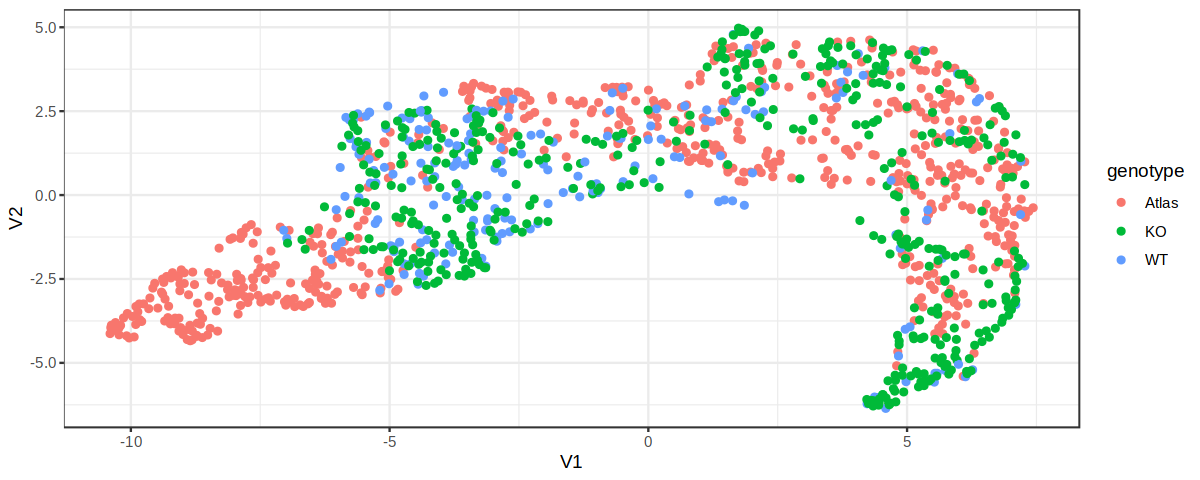

In [452]:
ggplot(to.plot, aes(V1, V2, color = genotype)) + 
    geom_point() + 
    theme_bw()

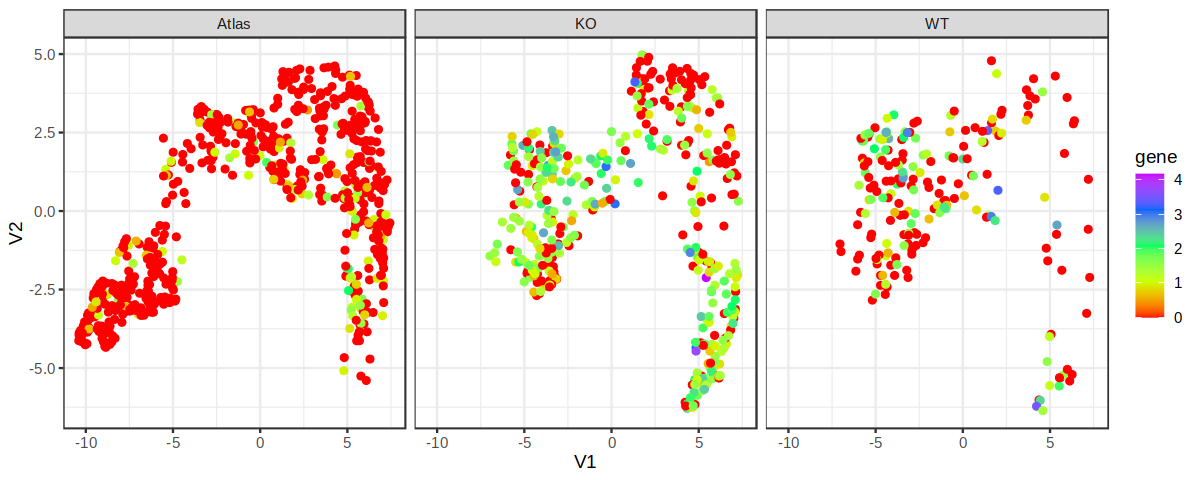

In [453]:
to.plot$gene = as.vector(logcounts(sce['Hand1',]))
options(repr.plot.height=4, repr.plot.width = 10)
ggplot(to.plot, aes(V1, V2, color = gene)) + 
    geom_point() + 
    scale_color_gradientn(colours = rainbow(5)) + 
    facet_wrap(~genotype) + 
    theme_bw()

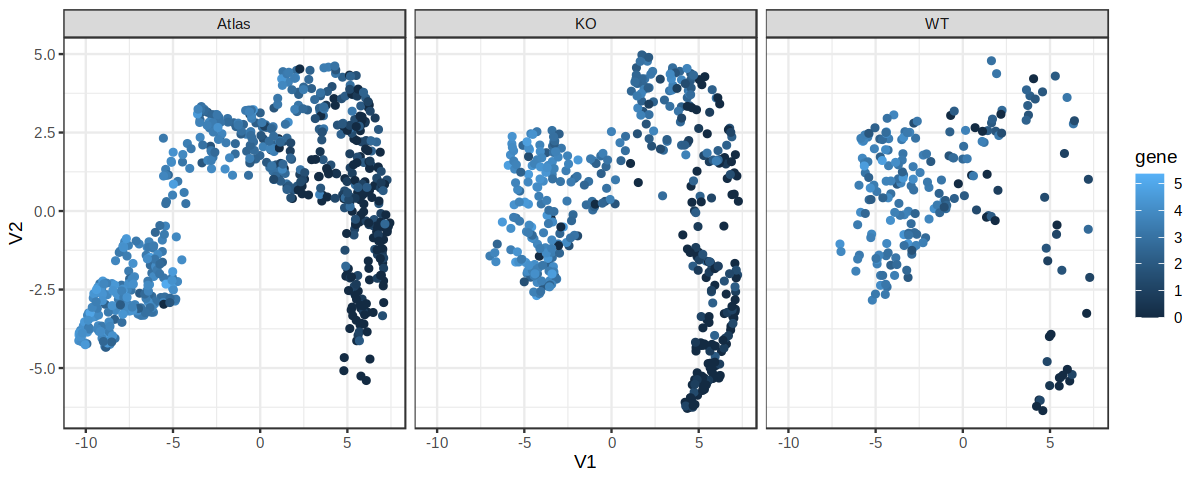

In [519]:
to.plot$gene = as.vector(logcounts(sce['Cdh5',]))
options(repr.plot.height=4, repr.plot.width = 10)
ggplot(to.plot, aes(V1, V2, color = gene)) + 
    geom_point() + 
    # scale_color_gradientn(colours = rainbow(5)) + 
    facet_wrap(~genotype) + 
    theme_bw()

In [535]:
to.plot[V1 > 0 & genotype == 'KO']

cell,V1,V2,genotype,gene
<chr>,<dbl>,<dbl>,<chr>,<dbl>
2_Eo_DEG_G9_day4_dTAG#AACAGATAGTTGGATC-1,5.428284,-2.1194662,KO,0.0000000
2_Eo_DEG_G9_day4_dTAG#GCATGAAAGCCTGTTC-1,2.302645,2.0670339,KO,1.6897802
2_Eo_DEG_G9_day5_dTAG#AAACCGCGTTAATGCG-1,7.017349,-3.4098135,KO,0.0000000
2_Eo_DEG_G9_day5_dTAG#AAAGCAAGTTGCTTCG-1,6.485919,1.7040402,KO,0.0000000
2_Eo_DEG_G9_day5_dTAG#AAATGGCCATGGTTAT-1,6.559795,1.4972338,KO,0.7405533
2_Eo_DEG_G9_day5_dTAG#AACAGGATCATCAGTA-1,5.855068,-5.2130500,KO,0.0000000
2_Eo_DEG_G9_day5_dTAG#AACCGCTCAGCTCATA-1,4.999488,2.6298338,KO,0.7443313
2_Eo_DEG_G9_day5_dTAG#AACCTTGCACATAACT-1,1.808300,4.9392093,KO,3.4660636
2_Eo_DEG_G9_day5_dTAG#AACTACTCAATCCTAG-1,4.261314,1.7901229,KO,3.5865820


In [528]:
seurat_tmp = as.Seurat(rna.sce[,to.plot[V1 < 0 & genotype != 'Atlas', cell]])
Idents(seurat_tmp) = seurat_tmp$genotype
markers = FindMarkers(seurat_tmp, ident.1 = 'WT')

In [533]:
as.data.table(markers, keep.rownames=T)[order(-avg_log2FC)]

rn,p_val,avg_log2FC,pct.1,pct.2,p_val_adj
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Hbb-bh1,2.133335e-50,1.8736530,0.871,0.017,6.887473e-46
Hba-x,4.911926e-37,1.6896717,0.679,0.000,1.585815e-32
Hba-a1,2.608099e-31,1.1435864,0.593,0.000,8.420247e-27
Kcnq5,7.971695e-15,0.9458391,0.700,0.310,2.573662e-10
Il31ra,2.265971e-14,0.8530522,0.636,0.339,7.315688e-10
Slc1a3,3.230994e-13,0.8317126,0.357,0.046,1.043126e-08
Runx1,3.413774e-12,0.7997813,0.579,0.259,1.102137e-07
Fermt3,1.970661e-17,0.7957981,0.579,0.155,6.362278e-13
Plxnc1,6.253186e-16,0.7925090,0.736,0.385,2.018841e-11


In [525]:
seurat_tmp$genotype

An object of class Seurat 
32285 features across 314 samples within 1 assay 
Active assay: RNA (32285 features, 0 variable features)

In [365]:
# Load Atlas
args$atlas.sce = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/endothelium/endothelium_sce.rds'
atlas.sce = load_SingleCellExperiment(args$atlas.sce, normalise = TRUE) 
atlas.sce = atlas.sce[,atlas.sce$seurat_cluster %in% c('EryP_progenitor')]

In [366]:
atlas_meta = colData(atlas.sce) %>% as.data.table(keep.rownames=T) %>% setnames('rn', 'cell')

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


### Integrate data

In [368]:
colnames(colData(rna.sce))
colnames(colData(atlas.sce))

[1] "barcode"                      "sample"                      
 [3] "nFeature_RNA"                 "nCount_RNA"                  
 [5] "mitochondrial_percent_RNA"    "ribosomal_percent_RNA"       
 [7] "alias"                        "day"                         
 [9] "genotype"                     "replicate"                   
[11] "pass_rnaQC"                   "doublet_score"               
[13] "doublet_call"                 "celltype.mapped_mnn"         
[15] "celltype.score_mnn"           "celltype_extended.mapped_mnn"
[17] "celltype_extended.score_mnn"  "stage.mapped_mnn"            
[19] "cellstage.score_mnn"          "closest.cell_mnn"            
[21] "celltype_genotype"            "celltype_extended_genotype"  
[23] "UMAP1"                        "UMAP2"                       
[25] "mofa_cluster"                 "celltype_v1"                 
[27] "celltype_v2"

[1] "barcode"                   "sample"                   
 [3] "nFeature_RNA"              "nCount_RNA"               
 [5] "mitochondrial_percent_RNA" "ribosomal_percent_RNA"    
 [7] "stage"                     "genotype"                 
 [9] "pass_rnaQC"                "doublet_score"            
[11] "doublet_call"              "celltype"                 
[13] "celltype.score"            "closest.cell"             
[15] "pass_atacQC"               "seurat_cluster"           
[17] "sizeFactor"

In [369]:
rna.sce2 = rna.sce
colData(rna.sce2) = colData(rna.sce2)[,c('genotype', 'barcode')]

atlas.sce2 = atlas.sce
colData(atlas.sce2) = colData(atlas.sce2)[,c('genotype', 'barcode')]

In [370]:
genes = intersect(rownames(rna.sce2), rownames(atlas.sce2))
sce = cbind(atlas.sce2[genes,], rna.sce2[genes,])

In [371]:
sce$genotype = ifelse(is.na(sce$genotype), 'Atlas', sce$genotype)

In [372]:
top_markers = subset_markers %>% 
    .[cluster != 'embryo'] %>%
    .[gene %in% rownames(rna.sce)]

In [373]:
nrow(top_markers)

[1] 238

In [374]:
library(batchelor)

In [421]:
decomp <- modelGeneVar(rna.sce2[genes,])
decomp <- decomp[decomp$mean > 0.01,]
hvgs <- decomp[order(decomp$FDR),] %>% head(n=5000) %>% rownames

In [422]:
head(hvgs, 20)

[1] "Ptprm"      "Meg3"       "Rian"       "Mast4"      "Airn"      
 [6] "Flt1"       "Col18a1"    "Ctla2a"     "Mecom"      "Hist1h2ap" 
[11] "Vcan"       "Rapgef5"    "Limch1"     "Hmga2"      "Dlk1"      
[16] "Unc5c"      "St6galnac3" "Edil3"      "Camk1d"     "Igf2"

In [423]:
pca.mtx <- multiBatchPCA(sce[hvgs,], 
                         batch = colData(sce)$genotype, 
                         d = 5,
                         preserve.single=TRUE, 
                         BPPARAM  = BPPARAM)[[1]]
colnames(pca.mtx) <- paste0("PC",1:ncol(pca.mtx))
reducedDim(sce, "PCA") <- pca.mtx[colnames(sce),]

In [424]:
pca.corrected <- reducedMNN(pca.mtx, batch = colData(sce)$genotype, auto.merge = TRUE)$corrected 


In [425]:
reducedDim(sce, "PCA_corrected") <- pca.corrected[colnames(sce),]

In [426]:
to.plot <- as.data.table(pca.corrected, keep.rownames=T) %>% setnames('rn', 'cell') %>% as.data.table %>% 
    .[,cell:=colnames(sce)] %>% 
    .[,genotype := colData(sce)$genotype]

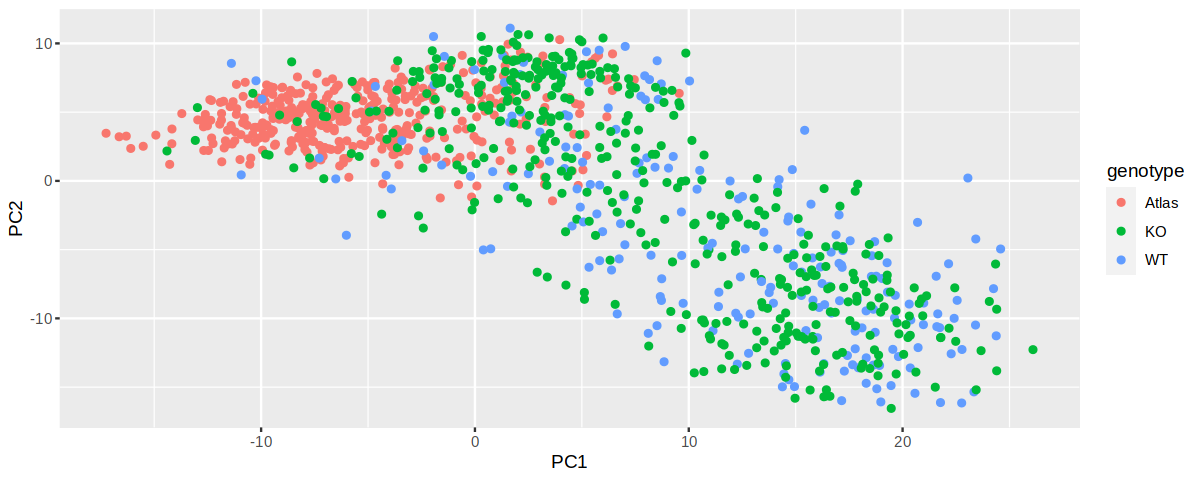

In [427]:
ggplot(to.plot, aes(PC1, PC2, color = genotype)) + 
    geom_point()

In [428]:
set.seed(1234)
args$min_dist = 0.3
args$n_neighbors = 15

umap.mtx = uwot::umap(reducedDim(sce, "PCA_corrected")[colnames(sce),], 
                n_neighbors = args$n_neighbors,
                min_dist = args$min_dist)

In [429]:
reducedDim(sce, "UMAP") <- umap.mtx[colnames(sce),]

In [430]:
to.plot <- as.data.table(umap.mtx, keep.rownames=T) %>% setnames('rn', 'cell') %>% as.data.table %>% 
    .[,cell:=colnames(sce)] %>% 
    .[,genotype := colData(sce)$genotype]

In [431]:
head(to.plot)

cell,V1,V2,genotype
<chr>,<dbl>,<dbl>,<chr>
E7.5_rep1#AAACCGGCAACCTAAT-1,0.1389774,2.932259,Atlas
E7.5_rep1#AACCTTAAGTCCTTTG-1,0.1372667,3.122648,Atlas
E7.5_rep1#AACGCCCAGGTCCAAT-1,-0.6465768,1.995777,Atlas
E7.5_rep1#AAGCCACGTCCGCTGT-1,-2.7358053,-1.124557,Atlas
E7.5_rep1#AAGCGCTGTTAAGCTG-1,0.4019182,2.148342,Atlas
E7.5_rep1#AAGGCCCTCACGAATC-1,-1.1144262,4.197917,Atlas


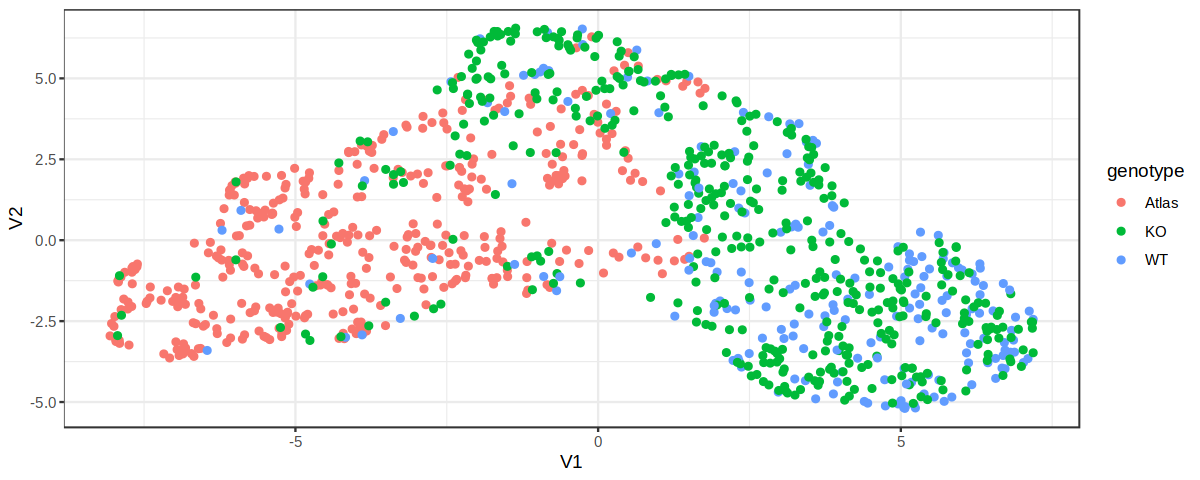

In [432]:
ggplot(to.plot, aes(V1, V2, color = genotype)) + 
    geom_point() + 
    theme_bw()

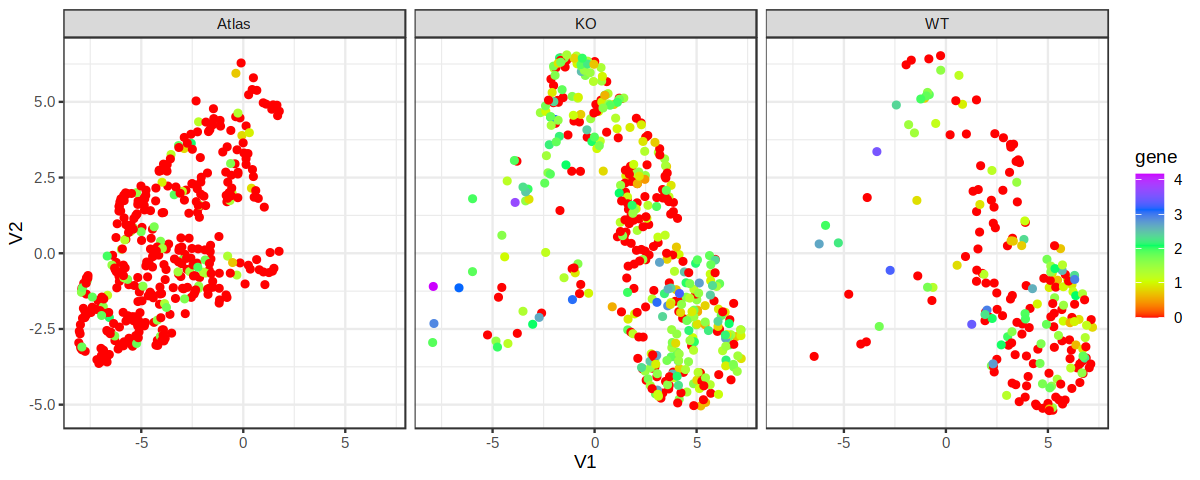

In [433]:
to.plot$gene = as.vector(logcounts(sce['Hand1',]))
options(repr.plot.height=4, repr.plot.width = 10)
ggplot(to.plot, aes(V1, V2, color = gene)) + 
    geom_point() + 
    scale_color_gradientn(colours = rainbow(5)) + 
    facet_wrap(~genotype) + 
    theme_bw()